In [1]:
import openmc
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
# Materials Definition
       
       #FUEL
        
uo2_fuel = openmc.Material(name="UO2 Fuel")
uo2_fuel.set_density('g/cc', 9.20)

uo2_fuel.add_nuclide("U234", 2.8563e-6, 'ao')
uo2_fuel.add_nuclide("U235", 4.8785e-4,'ao')
uo2_fuel.add_nuclide("U236", 3.5348e-6,'ao')
uo2_fuel.add_nuclide("U238", 2.0009e-2,'ao')
uo2_fuel.add_element("O", 4.1202e-2,'ao')

uo2_fuel.temperature = 295.15

       #ALUMINUM 6061
Al_6061 = openmc.Material(name='6061 Aluminum')
Al_6061.set_density('g/cc', 2.69)

Al_6061.add_element("Al", 5.8433e-2, 'ao')
Al_6061.add_element("Cr", 6.2310e-5, 'ao')
Al_6061.add_element("Cu", 6.3731e-5, 'ao')
Al_6061.add_element("Mg", 6.6651e-4, 'ao')
Al_6061.add_element("Mn", 2.2115e-5, 'ao')
Al_6061.add_element("Ti", 2.5375e-5, 'ao')
Al_6061.add_element("Zn", 3.0967e-5, 'ao')
Al_6061.add_element("Si", 3.4607e-4, 'ao')
Al_6061.add_element("Fe", 1.0152e-4, 'ao')

Al_6061.temperature = 295.15


       #ALUMINUM 1100
Al_1100 = openmc.Material(name='1100 Aluminum')
Al_1100.set_density('g/cc', 2.70)

Al_1100.add_element("Al", 5.9660e-2, 'ao')
Al_1100.add_element("Cu", 3.0705e-5, 'ao')
Al_1100.add_element("Mn", 7.3997e-6, 'ao')
Al_1100.add_element("Zn", 1.2433e-5, 'ao')
Al_1100.add_element("Si", 2.3302e-4, 'ao')
Al_1100.add_element("Fe", 1.1419e-4, 'ao')

Al_1100.temperature = 295.15

       #ALUMINUM 5052
Al_5052 = openmc.Material(name='5052 Aluminum')
Al_5052.set_density('g/cc', 2.69)

Al_5052.add_element("Al", 5.8028e-2, 'ao')
Al_5052.add_element("Cr", 7.7888e-5, 'ao')
Al_5052.add_element("Cu", 1.2746e-5, 'ao')
Al_5052.add_element("Mg", 1.6663e-3, 'ao')
Al_5052.add_element("Mn", 1.4743e-5, 'ao')
Al_5052.add_element("Zn", 1.2387e-5, 'ao')
Al_5052.add_element("Si", 1.2978e-4, 'ao')
Al_5052.add_element("Fe", 6.5265e-5, 'ao')

Al_5052.temperature = 295.15

       #Acrylic
acrylic = openmc.Material(name='Acrylic')
acrylic.set_density('g/cc', 1.185)

acrylic.add_element("H", 5.6642e-2, 'ao')
acrylic.add_element("C", 3.5648e-2, 'ao')
acrylic.add_element("O", 1.4273e-2, 'ao')

acrylic.temperature = 295.15  # 22°C

       #Water
water = openmc.Material(name="Water")
water.set_density('g/cc', 0.997766)

water.add_element("H", 6.6706e-2,'ao')
water.add_element("O", 3.3353e-2,'ao')
water.add_element("Gd", 3.9828e-8,'ao')

water.add_s_alpha_beta('c_H_in_H2O')
water.temperature = 295.15

materials = openmc.Materials([uo2_fuel, Al_6061, Al_1100, Al_5052, acrylic, water])
materials.export_to_xml()

In [3]:
#Fuel Rod Geometry

fuel_bottom = openmc.ZPlane(z0=1.27) 
fuel_top = openmc.ZPlane(z0=92.71)            #fuel length
fuel = openmc.ZCylinder(r=1.1176/2, name='Fuel')

clad_bottom = openmc.ZPlane(z0=0) 
clad_top = openmc.ZPlane(z0=93.19)            #clad length
clad_or = openmc.ZCylinder(r=0.635, name='Clad Outer R')  #clad outer diameter

top_plug_1_bottom = openmc.ZPlane(z0=92.71)  
top_plug_1_top = openmc.ZPlane(z0=93.19)       #top end plug lower peace length
top_plug_1 = openmc.ZCylinder(r=1.1176/2, name='Top end plug lower peace')

top_plug_2_bottom = openmc.ZPlane(z0=93.19)  
top_plug_2_top = openmc.ZPlane(z0=98.27)       #top end plug upper peace length
top_plug_2 = openmc.ZCylinder(r=0.635, name='Top end plug upper peace')

lower_plug_bottom = openmc.ZPlane(z0=0)
lower_plug_top = openmc.ZPlane(z0=1.27)         #lower end plug length
lower_plug = openmc.ZCylinder(r=0.635, name='Lower end plug')

#Region Definitions
assembly_pitch = 1.684

water_cell_x_min = openmc.XPlane(x0=-(assembly_pitch/2))
water_cell_x_max = openmc.XPlane(x0=+(assembly_pitch/2))
water_cell_y_min = openmc.YPlane(y0=-(assembly_pitch/2))
water_cell_y_max = openmc.YPlane(y0=+(assembly_pitch/2))
water_cell_top = openmc.ZPlane(z0=+98.27)
water_cell_bottom = openmc.ZPlane(z0=-2.54)

water_box_region = +water_cell_x_min & -water_cell_x_max & +water_cell_y_min & -water_cell_y_max & -water_cell_top & +water_cell_bottom



acrylic_bottom = openmc.ZPlane(z0=-2.54)            #Acrylic plate thickness
acrylic_top = openmc.ZPlane(z0=0)
acrylic_x_min = openmc.XPlane(x0=-assembly_pitch/2)
acrylic_x_max = openmc.XPlane(x0=+assembly_pitch/2)
acrylic_y_min = openmc.YPlane(y0=-assembly_pitch/2)
acrylic_y_max = openmc.YPlane(y0=+assembly_pitch/2)  #Acrylic plate width and depth

acrylic_region = +acrylic_x_min & -acrylic_x_max & +acrylic_y_min & -acrylic_y_max & +acrylic_bottom & -acrylic_top
fuel_region = -fuel & -fuel_top & +fuel_bottom
clad_region = +fuel & -clad_or & -clad_top & +clad_bottom
top_plug_1_region = -top_plug_1 & -top_plug_1_top & +top_plug_1_bottom
top_plug_2_region = -top_plug_2 & -top_plug_2_top & +top_plug_2_bottom
lower_plug_region = -lower_plug & -lower_plug_top & +lower_plug_bottom
water_region = water_box_region & ~(fuel_region | clad_region | top_plug_1_region | top_plug_2_region | lower_plug_region | acrylic_region)

#Cell Definitions

fuel_cell = openmc.Cell(name="Fuel_UO2")
fuel_cell.fill = uo2_fuel
fuel_cell.region = fuel_region

clad_cell = openmc.Cell(name="Clad")
clad_cell.fill = Al_6061
clad_cell.region = clad_region

top_plug_1_cell = openmc.Cell(name="Top end plug upper peace")
top_plug_1_cell.fill = Al_1100
top_plug_1_cell.region = top_plug_1_region
top_plug_2_cell = openmc.Cell(name="Top end plug lower peace")
top_plug_2_cell.fill = Al_1100
top_plug_2_cell.region = top_plug_2_region

lower_plug_cell = openmc.Cell(name="lower end plug")
lower_plug_cell.fill = Al_5052
lower_plug_cell.region = lower_plug_region

water_cell = openmc.Cell(name="water among rods")
water_cell.fill = water
water_cell.region = water_region

acrylic_cell = openmc.Cell(name="acrylic plate at the end")
acrylic_cell.fill = acrylic
acrylic_cell.region = acrylic_region
    
fuel_rod_universe = openmc.Universe(cells=[fuel_cell, clad_cell, top_plug_1_cell,
                                           top_plug_2_cell, lower_plug_cell, water_cell, acrylic_cell])

In [4]:
#Lattice Geometry
    #23x23.861

n_rows = 4
n_cols = 23

assembly = openmc.RectLattice(name='4x23 Assembly')
assembly.pitch = (assembly_pitch, assembly_pitch)

assembly.lower_left = [-assembly_pitch * n_rows / 2, -assembly_pitch * n_cols / 2]

assembly.universes = [
    [fuel_rod_universe for _ in range(n_rows)] for _ in range(n_cols)]

assembly_top = openmc.ZPlane(z0=+98.27)
assembly_bottom = openmc.ZPlane(z0=-2.54)

assembly_x_axis = assembly_pitch * n_rows
assembly_y_axis = assembly_pitch * n_cols

assembly_top = openmc.ZPlane(z0=+98.27)
assembly_bottom = openmc.ZPlane(z0=-2.54)
assembly_x_min = openmc.XPlane(x0=-assembly_x_axis/2)
assembly_x_max = openmc.XPlane(x0=+assembly_x_axis/2)
assembly_y_min = openmc.YPlane(y0=-assembly_y_axis/2)
assembly_y_max = openmc.YPlane(y0=+assembly_y_axis/2)

assembly_region = +assembly_x_min & -assembly_x_max & +assembly_y_min & -assembly_y_max & +assembly_bottom & -assembly_top

assembly_cell = openmc.Cell(name='4x23 assembly cell', fill=assembly, region=assembly_region)

In [5]:
#Extra Rod

n_extra_rows = 19
n_extra_cols = 24

x_axis_t = n_extra_rows+n_rows
y_axis_t = n_extra_cols

extra_rod = openmc.RectLattice(name='Extra Rod')
extra_rod.pitch = (assembly_pitch, assembly_pitch)

extra_rod.lower_left = [-(assembly_pitch * n_rows / 2)-n_extra_rows*assembly_pitch, -(assembly_pitch * n_cols / 2)-assembly_pitch]

extra_rod.universes = [[fuel_rod_universe for _ in range(n_extra_rows)] for _ in range(n_extra_cols)]

extra_rod_top = openmc.ZPlane(z0=+98.27)
extra_rod_bottom = openmc.ZPlane(z0=-2.54)

extra_rod_x_axis = assembly_pitch * (n_extra_rows+n_rows)
extra_rod_y_axis = assembly_pitch * n_extra_cols

extra_rod_top = openmc.ZPlane(z0=+98.27)
extra_rod_bottom = openmc.ZPlane(z0=-2.54)
extra_rod_x_min = openmc.XPlane(x0=-(assembly_x_axis/2)-n_extra_rows*assembly_pitch)
extra_rod_x_max = openmc.XPlane(x0=-assembly_x_axis/2)
extra_rod_y_min = openmc.YPlane(y0=-(assembly_y_axis/2)-assembly_pitch)
extra_rod_y_max = openmc.YPlane(y0=+assembly_y_axis/2)

extra_rod_region = +extra_rod_x_min & -extra_rod_x_max & +extra_rod_y_min & -extra_rod_y_max & +extra_rod_bottom & -extra_rod_top

extra_rod_cell = openmc.Cell(name='Extra Rod', fill=extra_rod, region=extra_rod_region)

In [6]:
#Outer Water Definitions

outer_water_universe = openmc.Universe()
outer_water_cell_for_lattice = openmc.Cell(fill=water)
outer_water_universe.add_cell(outer_water_cell_for_lattice)

assembly.outer = outer_water_universe
extra_rod.outer = outer_water_universe

outerwater_x_axis = ((x_axis_t)*assembly_pitch)+60         #30cm thick water reflector each side
outerwater_y_axis = ((y_axis_t)*assembly_pitch)+60

outerwater_bottom = openmc.ZPlane(z0=-(15.3+2.54), boundary_type='vacuum') #15.3cm bottom water reflector
outerwater_top = openmc.ZPlane(z0=+98.27+9.92, boundary_type='vacuum')      #9.92cm top water reflector

outerwater_x_min = openmc.XPlane(x0=-outerwater_x_axis/2, boundary_type='vacuum')
outerwater_x_max = openmc.XPlane(x0=+outerwater_x_axis/2, boundary_type='vacuum')
outerwater_y_min = openmc.YPlane(y0=-outerwater_y_axis/2, boundary_type='vacuum')
outerwater_y_max = openmc.YPlane(y0=+outerwater_y_axis/2, boundary_type='vacuum')

outerwater_cell = openmc.Cell(name="Outer Water Reflector")
outerwater_cell.fill = water
outerwater_region = +outerwater_x_min & -outerwater_x_max & +outerwater_y_min & -outerwater_y_max & +outerwater_bottom & -outerwater_top & ~assembly_region & ~extra_rod_region
outerwater_cell.region = outerwater_region

assembly_universe = openmc.Universe(cells=[assembly_cell, outerwater_cell, extra_rod_cell])

In [7]:
geometry = openmc.Geometry(assembly_universe)
geometry.export_to_xml()

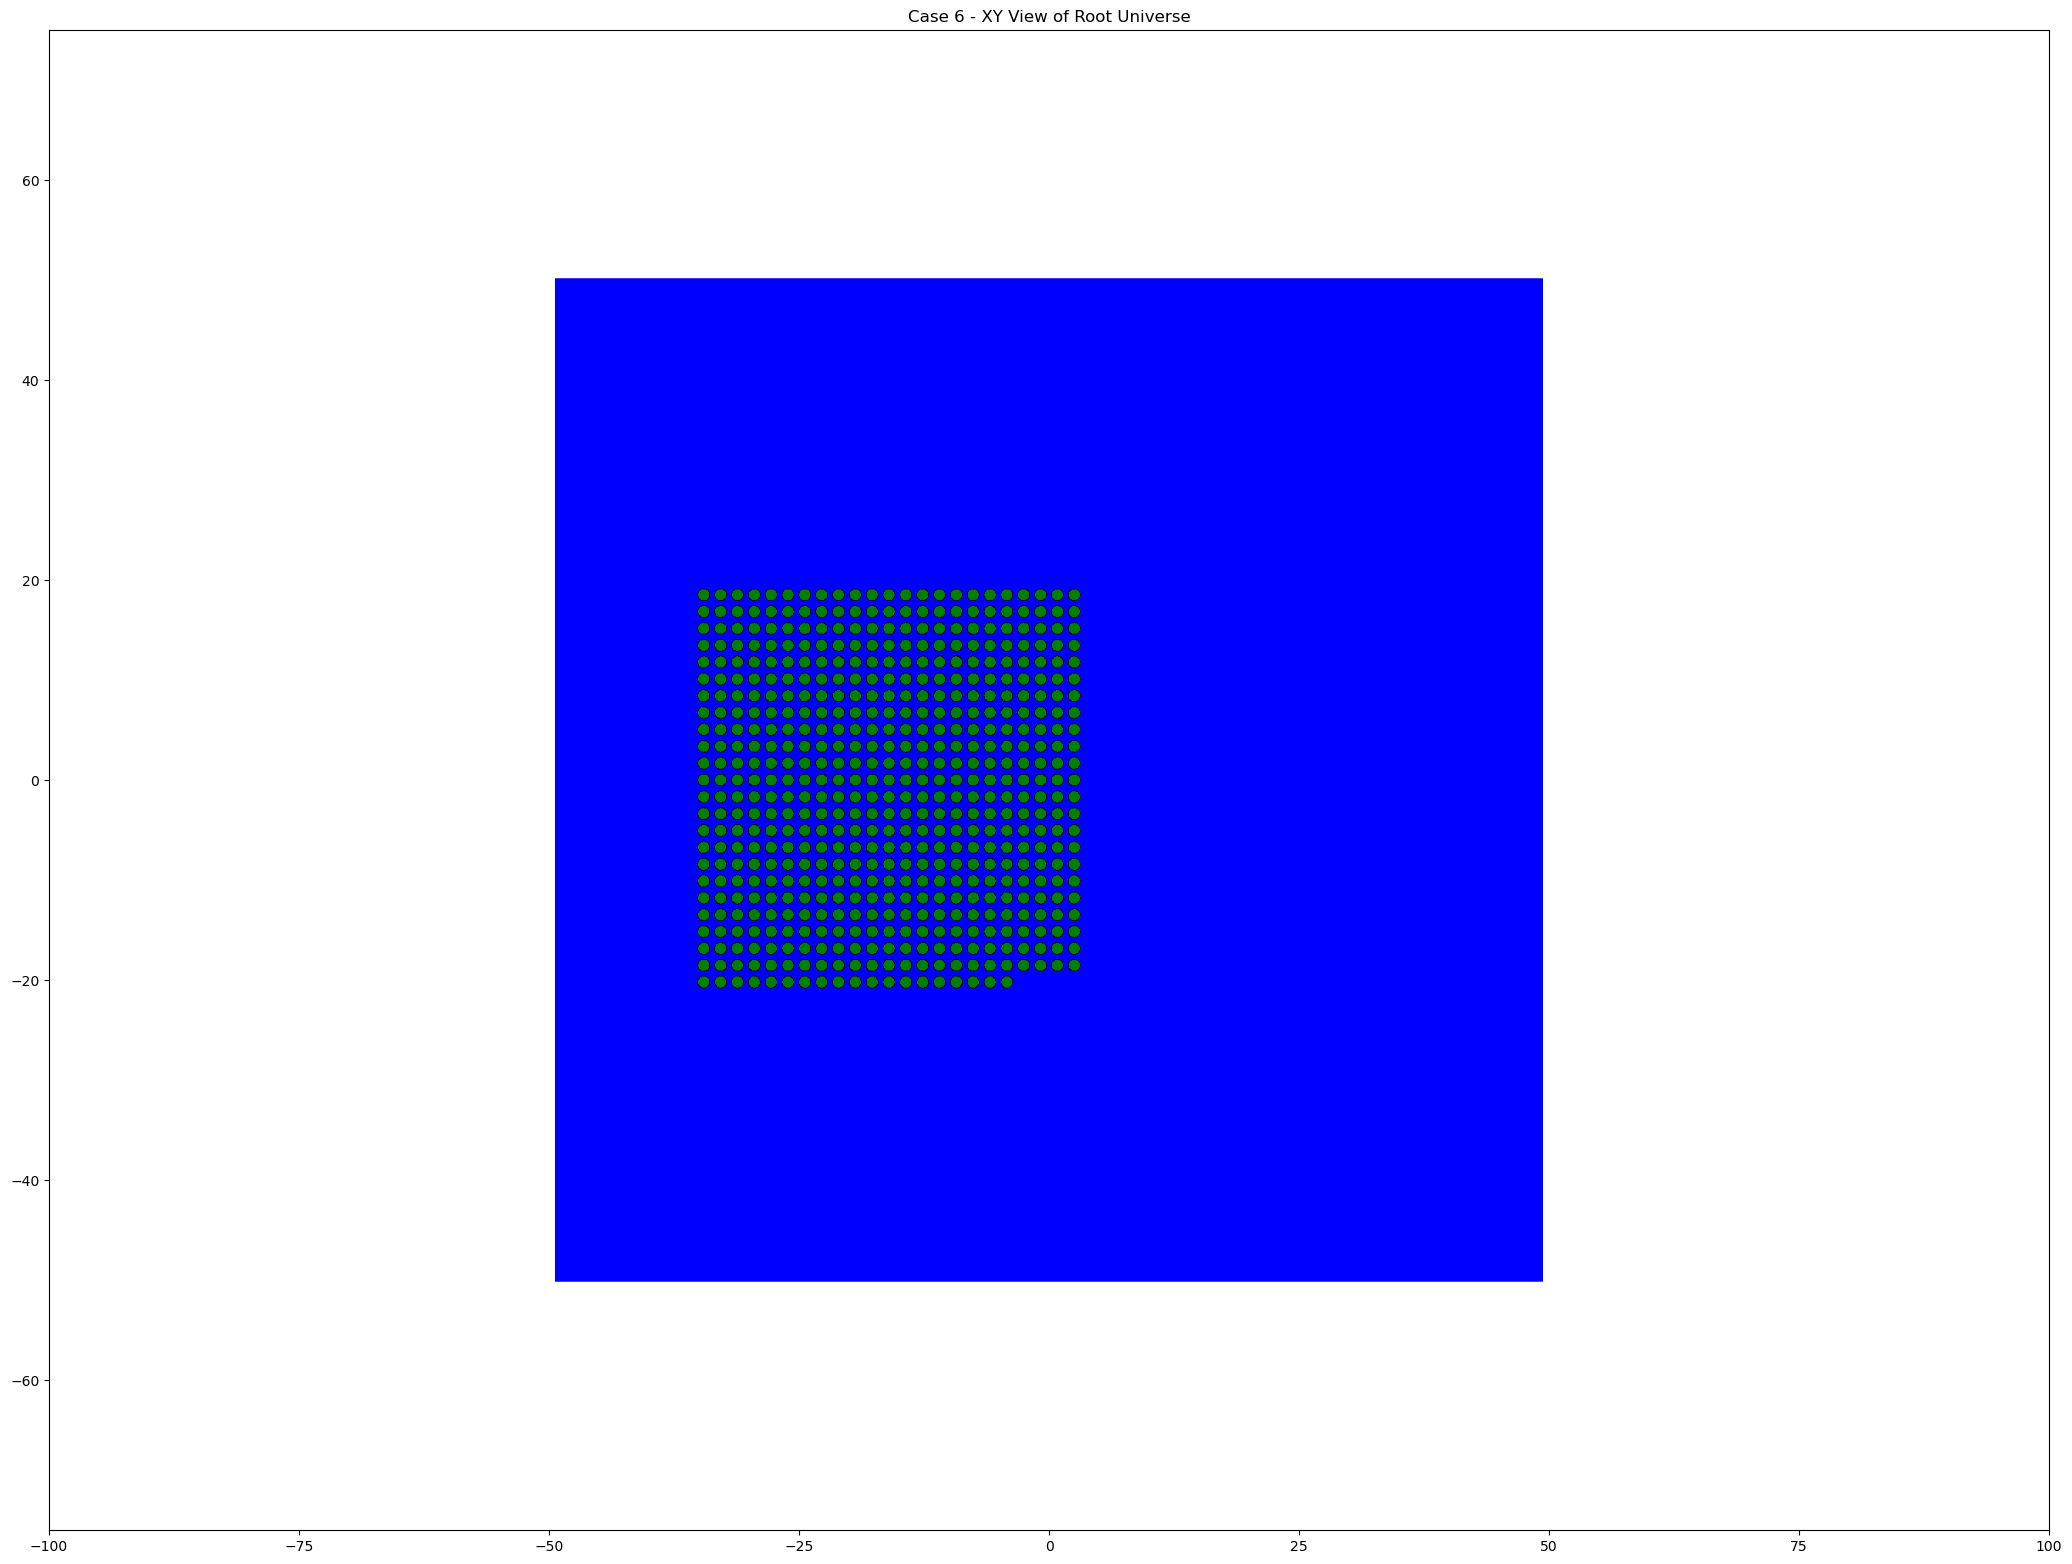

In [8]:
assembly_universe.plot(origin=(0, 0, 50), basis='xy', width=(200, 150), pixels=[2000, 2000],
                   color_by='material', colors={water: 'blue', uo2_fuel: 'green', Al_6061: 'black', Al_1100: 'pink', Al_5052: 'yellow', acrylic: 'purple'})
plt.title('Case 6 - XY View of Root Universe')
plt.savefig('case6_xy_view.pdf')
plt.show()

In [9]:
#Source definition

total_x = (assembly_pitch * n_rows) + assembly_pitch
total_y = (assembly_pitch * n_cols)

source = openmc.Source()
source.space = openmc.stats.Box(
    lower_left = (-total_x / 2, -total_y / 2, 1.27),
    upper_right = (total_x / 2, total_y / 2, 92.71)
)
source.angle = openmc.stats.Isotropic()
source.energy = openmc.stats.Watt(a=988000.0, b=2.249e-06)  # Watt spektrum

#Simulation Settings
settings = openmc.Settings()
settings.run_mode = 'eigenvalue'
settings.source = source
settings.batches = 160            # total = inactive + active
settings.inactive = 50
settings.particles = 1500       # number of particle for each batch
settings.seed = 123456

settings.export_to_xml()

# Tallies
fuel_tally = openmc.Tally(name="fuel_flux")
fuel_tally.filters = [openmc.CellFilter(fuel_cell)]
fuel_tally.scores = ["flux", "fission", "nu-fission", "heating-local"]  # MCNP F4, F6, F8

tallies = openmc.Tallies([fuel_tally])
tallies.export_to_xml()

openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################